In [16]:
#CH.SC.U4AIE24028
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
print("Loading MNIST dataset.")

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset Loaded Successfully!")
print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Loading MNIST dataset.
Dataset Loaded Successfully!
Features Shape: (70000, 784)
Labels Shape: (70000,)


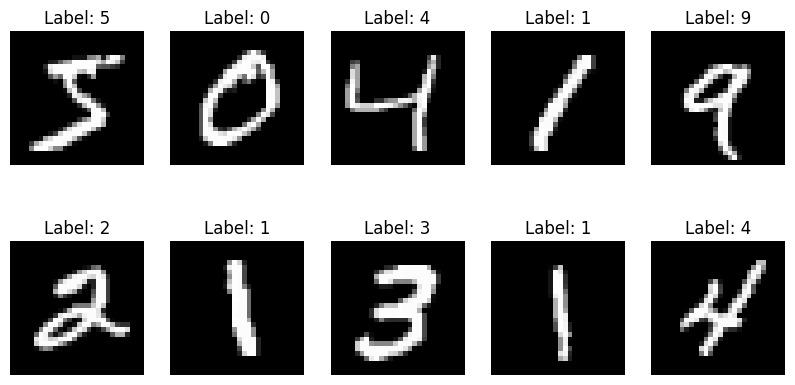

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28,28), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')

plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 56000
Testing Samples: 14000


In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data Normalized Successfully")

Data Normalized Successfully


In [6]:
perceptron = Perceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42
)

perceptron.fit(X_train, y_train)

print("Training Completed")

Training Completed


In [7]:
y_pred = perceptron.predict(X_test)

print("Prediction Completed")

Prediction Completed


In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 88.33 %


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1343
           1       0.93      0.95      0.94      1600
           2       0.85      0.89      0.87      1380
           3       0.86      0.85      0.85      1433
           4       0.89      0.91      0.90      1295
           5       0.84      0.85      0.84      1273
           6       0.93      0.93      0.93      1396
           7       0.87      0.90      0.89      1503
           8       0.83      0.79      0.81      1357
           9       0.87      0.81      0.84      1420

    accuracy                           0.88     14000
   macro avg       0.88      0.88      0.88     14000
weighted avg       0.88      0.88      0.88     14000



In [10]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1275    2   13    3    3    7   26    4    9    1]
 [   0 1514   12   15    2   14    3    4   35    1]
 [   7   20 1224   12   22   12   23   10   39   11]
 [   6   15   59 1217    5   46    8   22   31   24]
 [   2    5    8   11 1173   10    8   14   14   50]
 [  15    6   12   61   17 1077   16    7   45   17]
 [  12    6   43    0   12   15 1297    2    6    3]
 [   7    8   37    5   26    9    1 1358    7   45]
 [  10   37   22   57    7   87   17   15 1077   28]
 [   6   10    3   37   50    7    0  125   28 1154]]


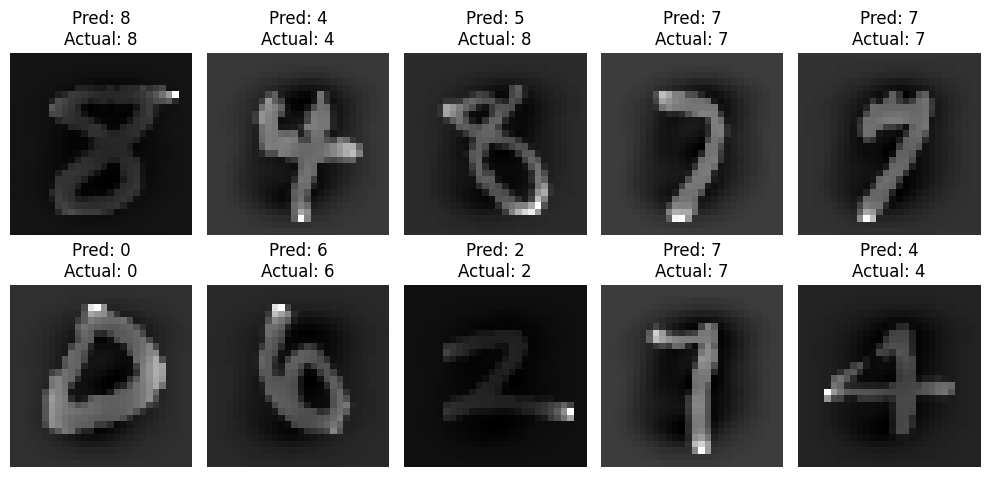

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28,28), cmap='gray')
    ax.set_title(
        f"Pred: {y_pred[i]}\nActual: {y_test[i]}"
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

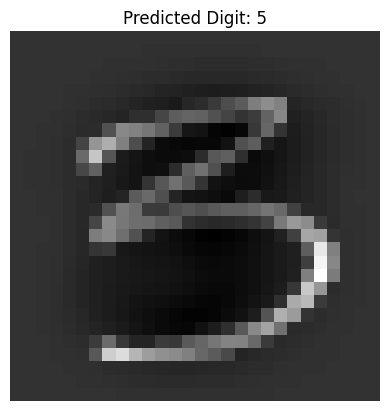

In [12]:
index = 100

sample = X_test[index].reshape(1,-1)

prediction = perceptron.predict(sample)

plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {prediction[0]}")
plt.axis('off')
plt.show()


Loading MNIST Dataset...
Dataset Shape: (70000, 784)
Labels Shape: (70000,)

Training MLP...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(



Accuracy: 97.52 %

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.97      0.97      0.97      1380
           3       0.97      0.97      0.97      1433
           4       0.97      0.98      0.98      1295
           5       0.97      0.97      0.97      1273
           6       0.98      0.99      0.98      1396
           7       0.97      0.98      0.97      1503
           8       0.97      0.96      0.96      1357
           9       0.97      0.96      0.97      1420

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000


Confusion Matrix:
[[1324    1    4    1    0    1    3    4    4    1]
 [   0 1581    3    5    1    0    2    6    2    0]
 [   2    8 1342    5    3    4    2    5    5    4]
 [   1    0    9 138

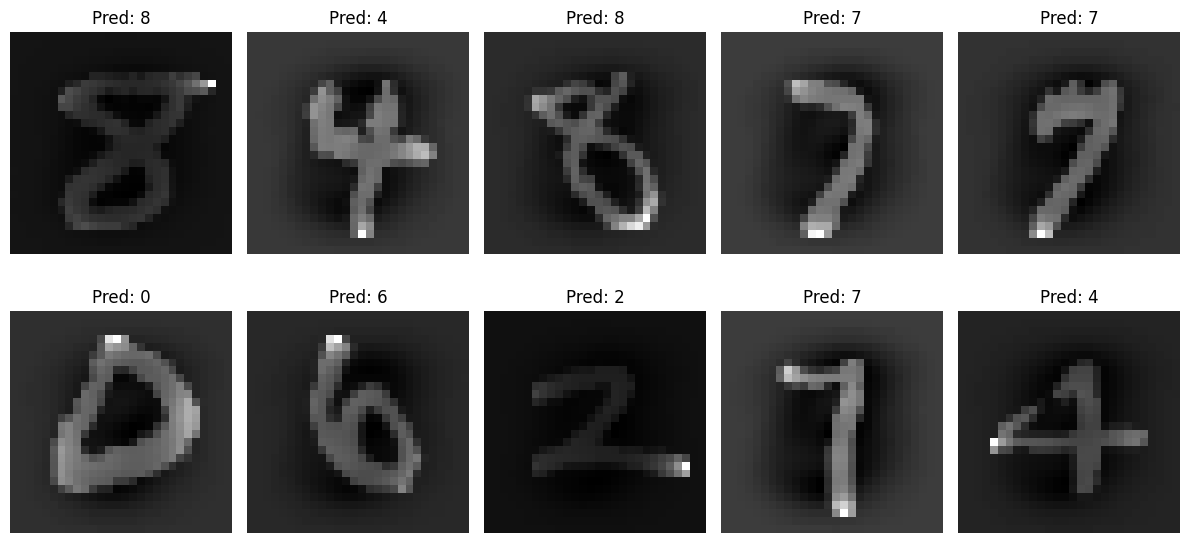

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load MNIST Dataset
print("Loading MNIST Dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Normalize Features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create MLP Model
mlp = MLPClassifier(
    hidden_layer_sizes=(128,),  # One Hidden Layer
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=20,
    random_state=42
)

print("\nTraining MLP...")
mlp.fit(X_train, y_train)

# Prediction
y_pred = mlp.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display Sample Predictions
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Loading MNIST Dataset...
Dataset Shape: (70000, 784)
Labels Shape: (70000,)

Training DNN...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(



Accuracy: 97.41 %

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.97      0.96      0.97      1380
           3       0.98      0.97      0.98      1433
           4       0.97      0.98      0.97      1295
           5       0.96      0.97      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.98      0.97      0.97      1503
           8       0.97      0.96      0.96      1357
           9       0.95      0.97      0.96      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000


Confusion Matrix:
[[1324    1    2    0    0    4    6    2    4    0]
 [   0 1581    6    0    0    2    0    8    2    1]
 [   2    9 1331    5    9    2    5    6    9    2]
 [   0    0   10 138

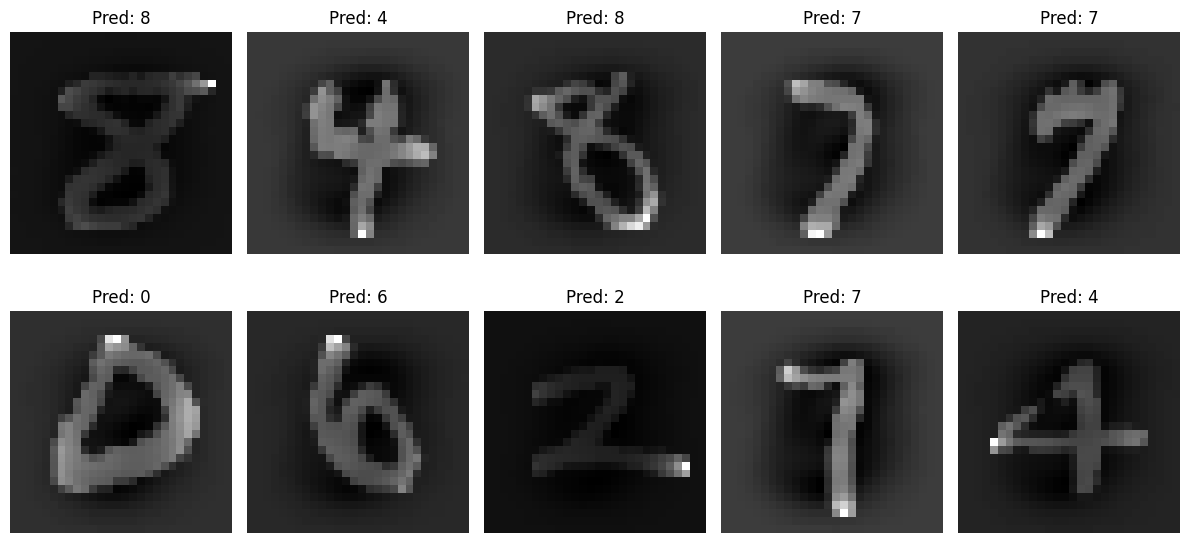

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load MNIST Dataset
print("Loading MNIST Dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Normalize Features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create Deep Neural Network
dnn = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),   # Multiple Hidden Layers
    activation='relu',
    solver='adam',
    batch_size=128,
    learning_rate_init=0.001,
    max_iter=30,
    random_state=42
)

print("\nTraining DNN...")
dnn.fit(X_train, y_train)

# Prediction
y_pred = dnn.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display Sample Predictions
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()